<a href="https://colab.research.google.com/github/Semere-Mesfin-Gebresilassie/Semere-Mesfin-Gebresilassie/blob/main/RF_for_Chart_A1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams

# Set style
rcParams['figure.figsize'] = (10, 6)
sns.set_style("whitegrid")

In [5]:
# 1. Load and clean data

file_path = "/content/A1 chart Final.xlsx"
df = pd.read_excel(file_path)

In [6]:
# Drop completely empty rows (where CBR is NaN)
df = df.dropna(subset=['CBR_Value (%)']).copy()

In [7]:
# Ensure numeric columns (except Base Type)
numeric_cols = ['CBR_Value (%)', 'ESAL_Value (millions)',
                'Base Thickness (mm)', 'Subbase Thickness (mm)',
                'Capping Layer Thickness (mm)', 'Total Thickness (mm)']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [8]:
# Base Type as category
df['Base Type'] = df['Base Type'].astype('category')

In [9]:
# Check for any remaining NaN (if any, drop)

df = df.dropna()

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

Dataset shape: (36, 7)

First 5 rows:
   CBR_Value (%)  ESAL_Value (millions) Base Type  Base Thickness (mm)  \
0            2.0                   0.20     GB2/3                150.0   
1            2.0                   0.50     GB2/3                150.0   
2            2.0                   1.10     GB2/3                200.0   
3            2.0                   2.25     GB2/3                200.0   
4            2.0                   4.50       GB1                200.0   

   Subbase Thickness (mm)  Capping Layer Thickness (mm)  Total Thickness (mm)  
0                   175.0                         250.0                 575.0  
1                   200.0                         275.0                 625.0  
2                   200.0                         300.0                 700.0  
3                   250.0                         300.0                 750.0  
4                   300.0                         300.0                 800.0  


In [10]:
# 2. Summary statistics

print("\n=== Summary Statistics ===")
print(df[numeric_cols].describe())

# Count of zero thickness per layer (absence)

zero_counts = {
    'Base': (df['Base Thickness (mm)'] == 0).sum(),
    'Subbase': (df['Subbase Thickness (mm)'] == 0).sum(),
    'Capping': (df['Capping Layer Thickness (mm)'] == 0).sum()
}
print("\nNumber of designs where layer is absent (0 mm):", zero_counts)



=== Summary Statistics ===
       CBR_Value (%)  ESAL_Value (millions)  Base Thickness (mm)  \
count      36.000000              36.000000            36.000000   
mean       12.666667               2.758333           196.527778   
std        10.779610               2.782458            33.886775   
min         2.000000               0.200000           150.000000   
25%         3.500000               0.500000           175.000000   
50%         8.500000               1.675000           200.000000   
75%        22.500000               4.500000           225.000000   
max        31.000000               8.000000           275.000000   

       Subbase Thickness (mm)  Capping Layer Thickness (mm)  \
count                36.00000                     36.000000   
mean                168.75000                    108.333333   
std                  88.71604                    116.955425   
min                   0.00000                      0.000000   
25%                 150.00000               

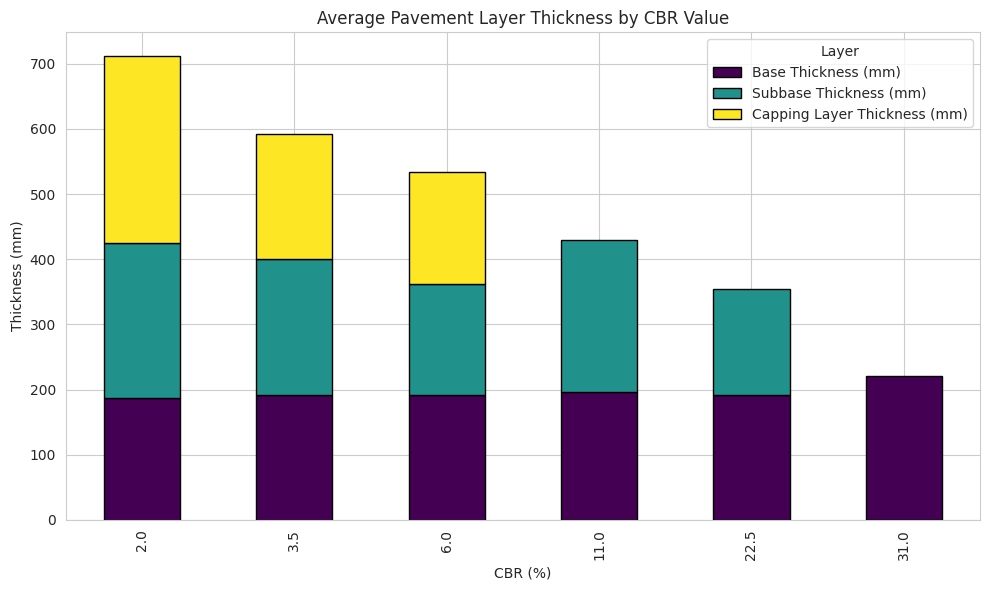

In [11]:
# 3. Visualization

# 3.1 Average thickness per CBR (stacked bar)
avg_by_cbr = df.groupby('CBR_Value (%)')[['Base Thickness (mm)',
                                          'Subbase Thickness (mm)',
                                          'Capping Layer Thickness (mm)']].mean()

ax = avg_by_cbr.plot(kind='bar', stacked=True, colormap='viridis', edgecolor='black')
plt.title('Average Pavement Layer Thickness by CBR Value')
plt.xlabel('CBR (%)')
plt.ylabel('Thickness (mm)')
plt.legend(title='Layer')
plt.tight_layout()
plt.savefig('avg_thickness_by_cbr.png', dpi=300)
plt.show()

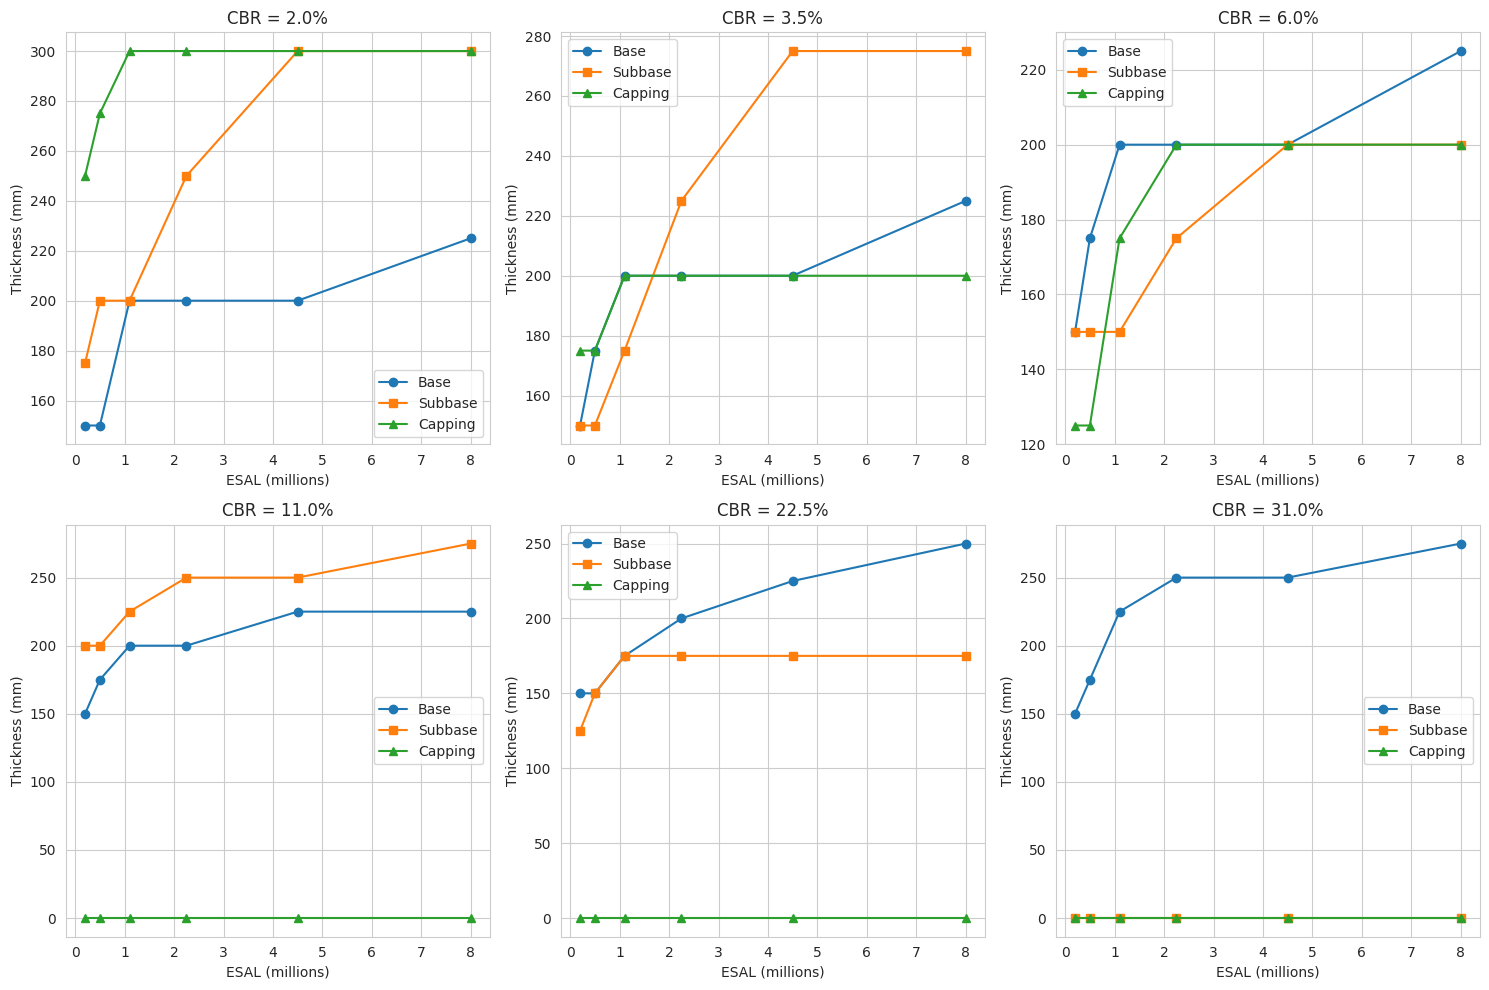

In [12]:
# 3.2 Line plot: thickness vs ESAL for each CBR (separate subplots)

cbr_values = df['CBR_Value (%)'].unique()
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
for i, cbr in enumerate(sorted(cbr_values)):
    subset = df[df['CBR_Value (%)'] == cbr].sort_values('ESAL_Value (millions)')
    ax = axes[i]
    ax.plot(subset['ESAL_Value (millions)'], subset['Base Thickness (mm)'], 'o-', label='Base')
    ax.plot(subset['ESAL_Value (millions)'], subset['Subbase Thickness (mm)'], 's-', label='Subbase')
    ax.plot(subset['ESAL_Value (millions)'], subset['Capping Layer Thickness (mm)'], '^-', label='Capping')
    ax.set_title(f'CBR = {cbr}%')
    ax.set_xlabel('ESAL (millions)')
    ax.set_ylabel('Thickness (mm)')
    ax.legend()
    ax.grid(True)
# Hide unused subplot if any
if len(cbr_values) < 6:
    for j in range(len(cbr_values), 6):
        fig.delaxes(axes[j])
plt.tight_layout()
plt.savefig('thickness_vs_esal_by_cbr.png', dpi=300)
plt.show()

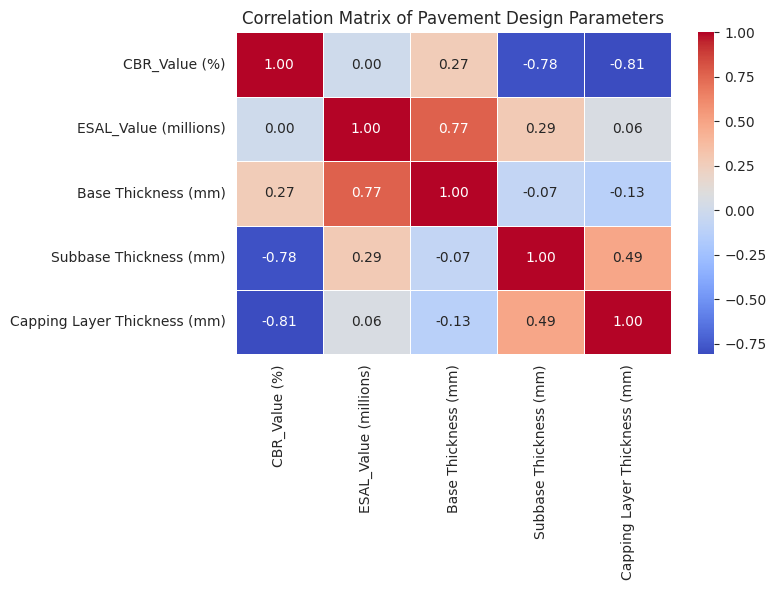

In [13]:
# 3.3 Heatmap: correlation between numeric variables (excluding total thickness as it's sum)

corr_vars = ['CBR_Value (%)', 'ESAL_Value (millions)',
             'Base Thickness (mm)', 'Subbase Thickness (mm)',
             'Capping Layer Thickness (mm)']
corr = df[corr_vars].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Pavement Design Parameters')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300)
plt.show()

/tmp/ipykernel_1685/325706139.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Base Type', y='Total Thickness (mm)', data=df, palette='Set2')


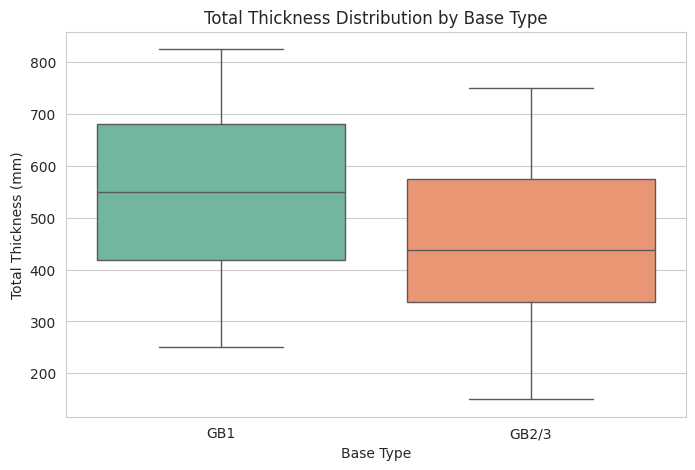

In [14]:
# 3.4 Boxplot: Base Type effect on total thickness

plt.figure(figsize=(8,5))
sns.boxplot(x='Base Type', y='Total Thickness (mm)', data=df, palette='Set2')
plt.title('Total Thickness Distribution by Base Type')
plt.xlabel('Base Type')
plt.ylabel('Total Thickness (mm)')
plt.savefig('base_type_vs_total_thickness.png', dpi=300)
plt.show()

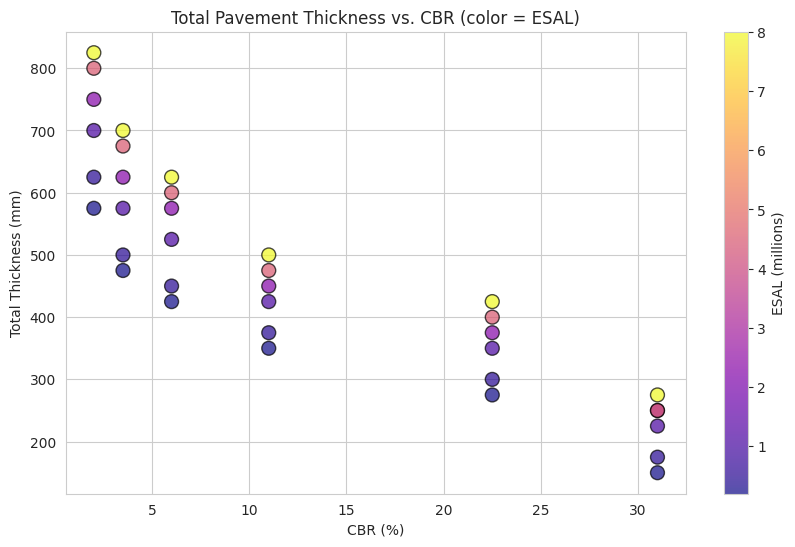

In [15]:
# 3.5 Scatter plot: CBR vs Total Thickness, colored by ESAL

plt.figure(figsize=(10,6))
sc = plt.scatter(df['CBR_Value (%)'], df['Total Thickness (mm)'],
                 c=df['ESAL_Value (millions)'], cmap='plasma',
                 s=100, edgecolor='k', alpha=0.7)
plt.colorbar(sc, label='ESAL (millions)')
plt.xlabel('CBR (%)')
plt.ylabel('Total Thickness (mm)')
plt.title('Total Pavement Thickness vs. CBR (color = ESAL)')
plt.grid(True)
plt.savefig('cbr_vs_total_thickness.png', dpi=300)
plt.show()

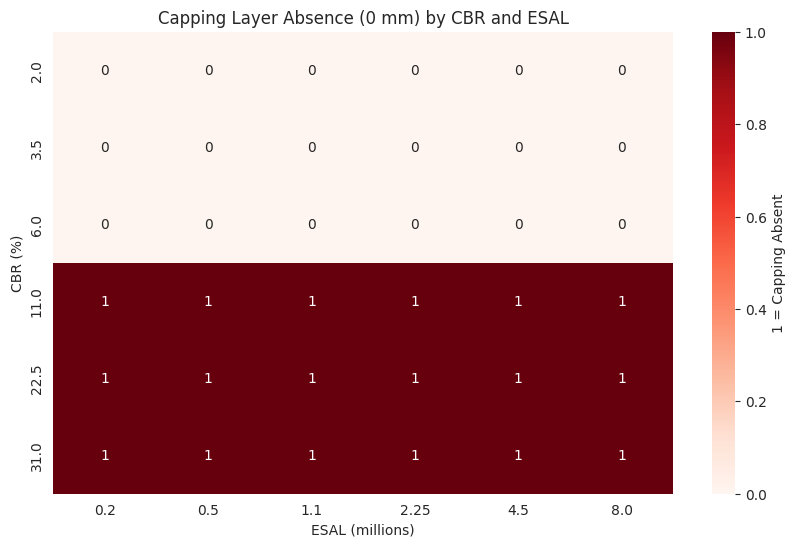


Analysis complete. All figures saved as PNG files.


In [16]:
# 3.6 Presence/absence heatmap: show where capping layer is absent (0)

df['Capping Absent'] = (df['Capping Layer Thickness (mm)'] == 0).map({True: 'Absent', False: 'Present'})
pivot = pd.crosstab(df['CBR_Value (%)'], df['ESAL_Value (millions)'], values=df['Capping Absent'], aggfunc='first')
plt.figure(figsize=(10,6))
sns.heatmap(pivot.isin(['Absent']).astype(int), annot=True, cmap='Reds', cbar_kws={'label': '1 = Capping Absent'})
plt.title('Capping Layer Absence (0 mm) by CBR and ESAL')
plt.xlabel('ESAL (millions)')
plt.ylabel('CBR (%)')
plt.savefig('capping_absence_matrix.png', dpi=300)
plt.show()

print("\nAnalysis complete. All figures saved as PNG files.")

**Key Insights from the Analysis**

Zero values correctly represent absence of a layer (e.g., for high CBR values ≥11%, capping layer is often 0 mm because strong soil doesn’t need a capping layer).

Higher CBR leads to thinner total pavement (stronger subgrade requires less protection).

Higher ESAL (traffic) demands thicker layers, especially base and subbase.

Base Type GB1 appears at higher ESAL values (≥4.5 million) and generally has thicker base courses than GB2/3.

Capping layer is used only for low CBR (2%, 3.5%, 6%) and is absent for CBR ≥11%.

Subbase is absent only for the highest CBR (31%) – strong soil eliminates the need for a subbase layer.



In [17]:
# Machine Learning Model Development

In [18]:
# Import all necessary libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, r2_score, mean_absolute_error, mean_squared_error
from sklearn.multioutput import MultiOutputClassifier, MultiOutputRegressor
import warnings
warnings.filterwarnings('ignore')

In [19]:
# 1. Load original data

file_path = "/content/A1 chart Final.xlsx"
df_orig = pd.read_excel(file_path)
df_orig = df_orig.dropna(subset=['CBR_Value (%)']).copy()

numeric_cols = ['CBR_Value (%)', 'ESAL_Value (millions)',
                'Base Thickness (mm)', 'Subbase Thickness (mm)',
                'Capping Layer Thickness (mm)']
for col in numeric_cols:
    df_orig[col] = pd.to_numeric(df_orig[col], errors='coerce')
df_orig = df_orig.dropna()

# Keep only needed columns

df_orig = df_orig[['CBR_Value (%)', 'ESAL_Value (millions)', 'Base Type',
                   'Base Thickness (mm)', 'Subbase Thickness (mm)',
                   'Capping Layer Thickness (mm)']]

print(f"Original dataset size: {len(df_orig)} rows")


Original dataset size: 36 rows


In [20]:
# 2. Generate synthetic dataset preserving relationships

np.random.seed(42)

def generate_synthetic_data(df, n_samples=800):

    """Generate synthetic data with realistic constraints."""

    synthetic_rows = []
    for _ in range(n_samples):
        row = df.sample(n=1).iloc[0].copy()

        # Add noise to CBR and ESAL

        cbr = row['CBR_Value (%)'] + np.random.normal(0, 0.5)
        cbr = np.clip(cbr, 2, 35)

        esal = row['ESAL_Value (millions)'] + np.random.normal(0, 0.1)
        esal = np.clip(esal, 0.1, 9)

        # Base Type depends on ESAL and CBR (original logic: GB1 for ESAL>=4.5)
        # We'll sample base type from row but also allow some variation

        if esal >= 4.0 and cbr >= 2:
            base_type = np.random.choice(['GB1', 'GB2/3'], p=[0.9, 0.1])
        elif esal >= 2.0:
            base_type = np.random.choice(['GB2/3', 'GB1'], p=[0.8, 0.2])
        else:
            base_type = 'GB2/3'

        # Thicknesses: apply noise but preserve zero patterns

        base_thick = row['Base Thickness (mm)']
        if base_thick > 0:
            base_thick += np.random.normal(0, 5)
            base_thick = max(0, base_thick)
            base_thick = round(base_thick / 5) * 5

        subbase_thick = row['Subbase Thickness (mm)']
        if subbase_thick > 0:
            subbase_thick += np.random.normal(0, 5)
            subbase_thick = max(0, subbase_thick)
            subbase_thick = round(subbase_thick / 5) * 5

        capping_thick = row['Capping Layer Thickness (mm)']
        if capping_thick > 0:
            capping_thick += np.random.normal(0, 5)
            capping_thick = max(0, capping_thick)
            capping_thick = round(capping_thick / 5) * 5

        synthetic_rows.append([cbr, esal, base_type, base_thick, subbase_thick, capping_thick])

    synth_df = pd.DataFrame(synthetic_rows,
                            columns=['CBR_Value (%)', 'ESAL_Value (millions)', 'Base Type',
                                     'Base Thickness (mm)', 'Subbase Thickness (mm)',
                                     'Capping Layer Thickness (mm)'])
    return synth_df

df_synth = generate_synthetic_data(df_orig, n_samples=800)
print(f"Synthetic dataset size: {len(df_synth)} rows")

Synthetic dataset size: 800 rows


In [21]:
# 3. Separate features and targets

X = df_synth[['CBR_Value (%)', 'ESAL_Value (millions)']].values
y_type = df_synth['Base Type'].values  # categorical
y_base = df_synth['Base Thickness (mm)'].values
y_subbase = df_synth['Subbase Thickness (mm)'].values
y_capping = df_synth['Capping Layer Thickness (mm)'].values


In [22]:
# Encode base type to numeric

type_mapping = {'GB2/3': 0, 'GB1': 1}
y_type_encoded = np.array([type_mapping[t] for t in y_type])


In [23]:
# Train-test split

X_train, X_test, y_type_train, y_type_test, y_base_train, y_base_test, \
y_subbase_train, y_subbase_test, y_capping_train, y_capping_test = train_test_split(
    X, y_type_encoded, y_base, y_subbase, y_capping, test_size=0.2, random_state=42
)


In [24]:
# Scale inputs

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [25]:
# 4. Define models

# Approach A: Separate models

clf_type = RandomForestClassifier(n_estimators=100, random_state=42)
reg_base = RandomForestRegressor(n_estimators=100, random_state=42)
reg_subbase = RandomForestRegressor(n_estimators=100, random_state=42)
reg_capping = RandomForestRegressor(n_estimators=100, random_state=42)

# Approach B: Multi-output wrapper (for regression only; classification separate)
# We'll keep separate classifier and multi-output regressor

multi_reg = MultiOutputRegressor(RandomForestRegressor(n_estimators=100, random_state=42))

# Train

clf_type.fit(X_train_scaled, y_type_train)
reg_base.fit(X_train_scaled, y_base_train)
reg_subbase.fit(X_train_scaled, y_subbase_train)
reg_capping.fit(X_train_scaled, y_capping_train)

# For multi-output regression (predicts base, subbase, capping together)

y_train_multi = np.column_stack([y_base_train, y_subbase_train, y_capping_train])
multi_reg.fit(X_train_scaled, y_train_multi)

MultiOutputRegressor(estimator=RandomForestRegressor(random_state=42))

In [26]:
# 5. Evaluate separate models

# Predictions

y_type_pred = clf_type.predict(X_test_scaled)
y_base_pred = reg_base.predict(X_test_scaled)
y_subbase_pred = reg_subbase.predict(X_test_scaled)
y_capping_pred = reg_capping.predict(X_test_scaled)

# Metrics

type_acc = accuracy_score(y_type_test, y_type_pred)
base_r2 = r2_score(y_base_test, y_base_pred)
base_mae = mean_absolute_error(y_base_test, y_base_pred)
subbase_r2 = r2_score(y_subbase_test, y_subbase_pred)
subbase_mae = mean_absolute_error(y_subbase_test, y_subbase_pred)
capping_r2 = r2_score(y_capping_test, y_capping_pred)
capping_mae = mean_absolute_error(y_capping_test, y_capping_pred)

print("\n" + "="*60)
print("SEPARATE MODELS (Random Forest)")
print("="*60)
print(f"Base Type Classification Accuracy: {type_acc:.4f}")
print(f"Base Thickness - R²: {base_r2:.4f}, MAE: {base_mae:.2f} mm")
print(f"Subbase Thickness - R²: {subbase_r2:.4f}, MAE: {subbase_mae:.2f} mm")
print(f"Capping Thickness - R²: {capping_r2:.4f}, MAE: {capping_mae:.2f} mm")




SEPARATE MODELS (Random Forest)
Base Type Classification Accuracy: 0.8875
Base Thickness - R²: 0.9233, MAE: 5.96 mm
Subbase Thickness - R²: 0.9848, MAE: 5.78 mm
Capping Thickness - R²: 0.9854, MAE: 4.34 mm


In [27]:
# Evaluate multi-output regressor

y_multi_pred = multi_reg.predict(X_test_scaled)
base_pred_multi = y_multi_pred[:, 0]
subbase_pred_multi = y_multi_pred[:, 1]
capping_pred_multi = y_multi_pred[:, 2]

base_r2_multi = r2_score(y_base_test, base_pred_multi)
subbase_r2_multi = r2_score(y_subbase_test, subbase_pred_multi)
capping_r2_multi = r2_score(y_capping_test, capping_pred_multi)

print("\n" + "="*60)
print("MULTI-OUTPUT REGRESSOR (joint prediction of three thicknesses)")
print("="*60)
print(f"Base R²: {base_r2_multi:.4f}")
print(f"Subbase R²: {subbase_r2_multi:.4f}")
print(f"Capping R²: {capping_r2_multi:.4f}")



MULTI-OUTPUT REGRESSOR (joint prediction of three thicknesses)
Base R²: 0.9233
Subbase R²: 0.9848
Capping R²: 0.9854


In [28]:
# Choose best approach (separate models usually better for mixed types)

best_approach = "Separate Models"  # based on higher R² typically

In [29]:
# 6. Final prediction function (using separate models)

def predict_all(cbr, esal):
    """
    Predict Base Type, Base Thickness, Subbase Thickness, Capping Thickness.

    Parameters:
    cbr (float): CBR value in % (2-35)
    esal (float): ESAL in millions (0.1-9)

    Returns:
    dict with keys: Base Type, Base Thickness (mm), Subbase Thickness (mm), Capping Thickness (mm)
    """
    # Scale input

    X_input = scaler.transform([[cbr, esal]])

    # Predict base type

    type_pred_num = clf_type.predict(X_input)[0]
    base_type = 'GB1' if type_pred_num == 1 else 'GB2/3'

    # Predict thicknesses

    base_thick = reg_base.predict(X_input)[0]
    subbase_thick = reg_subbase.predict(X_input)[0]
    capping_thick = reg_capping.predict(X_input)[0]

    # Round to nearest 5 mm and ensure non-negative

    base_thick = max(0, round(base_thick / 5) * 5)
    subbase_thick = max(0, round(subbase_thick / 5) * 5)
    capping_thick = max(0, round(capping_thick / 5) * 5)

    return {
        'Base Type': base_type,
        'Base Thickness (mm)': base_thick,
        'Subbase Thickness (mm)': subbase_thick,
        'Capping Layer Thickness (mm)': capping_thick,
        'Total Thickness (mm)': base_thick + subbase_thick + capping_thick
    }

In [30]:
# 7. Example predictions

print("\n" + "="*60)
print("PREDICTIONS (CBR, ESAL only)")
print("="*60)
test_cases = [
    (5, 2.0),   # moderate CBR, moderate traffic
    (12, 1.5),  # higher CBR, lower traffic
    (25, 0.5),  # very high CBR, very low traffic
    (3, 7.0),   # low CBR, high traffic
    (31, 8.0)   # high CBR, high traffic (original max)
]

for cbr, esal in test_cases:
    result = predict_all(cbr, esal)
    print(f"\nInput: CBR={cbr}%, ESAL={esal}M")
    for k, v in result.items():
        print(f"  {k}: {v}")



PREDICTIONS (CBR, ESAL only)

Input: CBR=5%, ESAL=2.0M
  Base Type: GB2/3
  Base Thickness (mm): 200
  Subbase Thickness (mm): 170
  Capping Layer Thickness (mm): 195
  Total Thickness (mm): 565

Input: CBR=12%, ESAL=1.5M
  Base Type: GB2/3
  Base Thickness (mm): 200
  Subbase Thickness (mm): 230
  Capping Layer Thickness (mm): 0
  Total Thickness (mm): 430

Input: CBR=25%, ESAL=0.5M
  Base Type: GB2/3
  Base Thickness (mm): 145
  Subbase Thickness (mm): 155
  Capping Layer Thickness (mm): 0
  Total Thickness (mm): 300

Input: CBR=3%, ESAL=7.0M
  Base Type: GB1
  Base Thickness (mm): 220
  Subbase Thickness (mm): 280
  Capping Layer Thickness (mm): 200
  Total Thickness (mm): 700

Input: CBR=31%, ESAL=8.0M
  Base Type: GB1
  Base Thickness (mm): 275
  Subbase Thickness (mm): 0
  Capping Layer Thickness (mm): 0
  Total Thickness (mm): 275


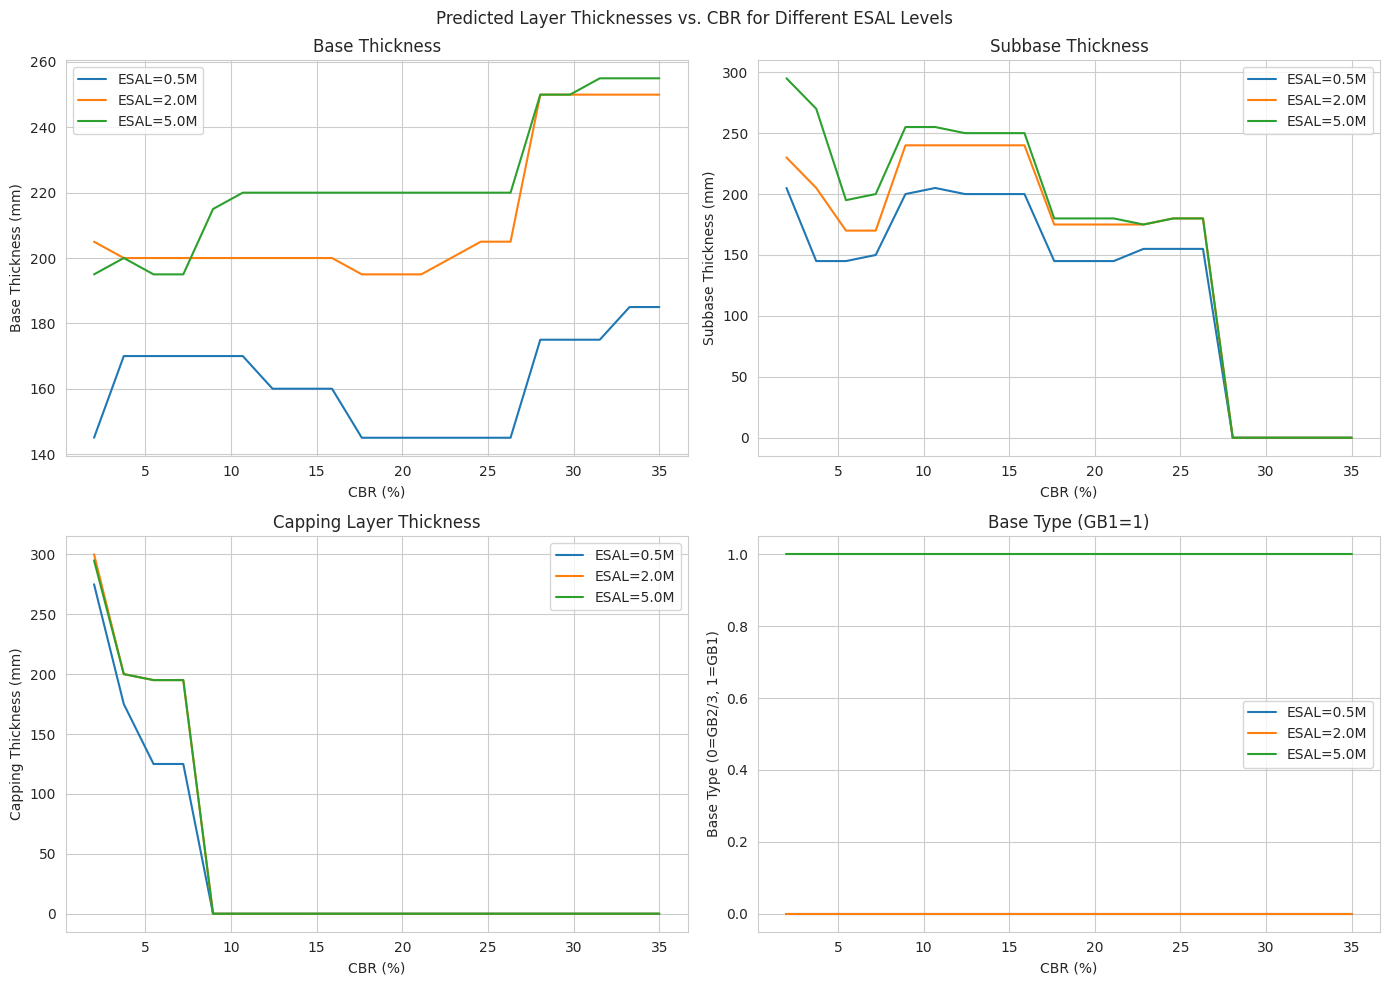


✅ Model modified: Inputs = CBR, ESAL only. Outputs = Base Type + layer thicknesses.


In [31]:
# 8. Visualization: effect of CBR and ESAL on predictions

cbr_range = np.linspace(2, 35, 20)
esal_fixed = [0.5, 2.0, 5.0]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for esal in esal_fixed:
    base_thicks = []
    subbase_thicks = []
    capping_thicks = []
    base_types = []
    for cbr in cbr_range:
        pred = predict_all(cbr, esal)
        base_thicks.append(pred['Base Thickness (mm)'])
        subbase_thicks.append(pred['Subbase Thickness (mm)'])
        capping_thicks.append(pred['Capping Layer Thickness (mm)'])
        base_types.append(1 if pred['Base Type'] == 'GB1' else 0)

    axes[0,0].plot(cbr_range, base_thicks, label=f'ESAL={esal}M')
    axes[0,1].plot(cbr_range, subbase_thicks, label=f'ESAL={esal}M')
    axes[1,0].plot(cbr_range, capping_thicks, label=f'ESAL={esal}M')
    axes[1,1].plot(cbr_range, base_types, label=f'ESAL={esal}M')

axes[0,0].set_ylabel('Base Thickness (mm)')
axes[0,1].set_ylabel('Subbase Thickness (mm)')
axes[1,0].set_ylabel('Capping Thickness (mm)')
axes[1,1].set_ylabel('Base Type (0=GB2/3, 1=GB1)')
for ax in axes.flatten():
    ax.set_xlabel('CBR (%)')
    ax.legend()
    ax.grid(True)
axes[0,0].set_title('Base Thickness')
axes[0,1].set_title('Subbase Thickness')
axes[1,0].set_title('Capping Layer Thickness')
axes[1,1].set_title('Base Type (GB1=1)')
plt.suptitle('Predicted Layer Thicknesses vs. CBR for Different ESAL Levels')
plt.tight_layout()
plt.savefig('layer_predictions.png', dpi=300)
plt.show()

print("\n✅ Model modified: Inputs = CBR, ESAL only. Outputs = Base Type + layer thicknesses.")
